# FINAL — Transformer Set Deep SVDD per Emerging Jets

Questo notebook adatta il notebook `transformer_deep_svdd_jets_tracks.ipynb` alla pipeline `FINAL`.

Input previsto:

```text
FINAL/processed/repr2_sequences.npz
```

Usa la rappresentazione sequenziale creata dal preprocessing:

```text
X_bkg_train       -> tracce padded QCD train
mask_bkg_train    -> mask tracce valide QCD train
jet_bkg_train     -> feature jet QCD train

X_bkg_eval        -> tracce padded QCD eval
mask_bkg_eval     -> mask tracce valide QCD eval
jet_bkg_eval      -> feature jet QCD eval

X_sig             -> tracce padded signal EJ
mask_sig          -> mask tracce valide signal EJ
jet_sig           -> feature jet signal EJ
```

Schema:

```text
bkg_train -> training Deep SVDD
bkg_eval  -> diviso in validation QCD + test QCD
sig       -> test signal EJ
```

Il modello è unsupervised:

```text
training: solo QCD/background
score: distanza dal centro SVDD nello spazio latente
```

Questo notebook non rilegge gli HDF5 e non rifà il preprocessing.

## 1. Import, seed e device

In [1]:
from pathlib import Path
import json
import copy
import math
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

try:
    torch.set_float32_matmul_precision("high")
except Exception:
    pass

print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("GPU count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Torch: 2.11.0+cu128
CUDA available: True
CUDA version: 12.8
GPU count: 1
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
Using device: cuda


## 2. Path e caricamento `repr2_sequences.npz`

In [2]:
# Funziona sia se il notebook è lanciato da FINAL/notebooks,
# sia se è lanciato dalla root del progetto.

CANDIDATE_BASES = [
    Path(".."),
    Path("."),
    Path("FINAL"),
]

PROCESSED_PATH = None

for base in CANDIDATE_BASES:
    candidate = base / "processed" / "repr2_sequences.npz"
    if candidate.exists():
        PROCESSED_PATH = candidate
        PROJECT_BASE = base
        break

if PROCESSED_PATH is None:
    raise FileNotFoundError(
        "Non trovo repr2_sequences.npz. "
        "Controlla che esista in FINAL/processed/repr2_sequences.npz "
        "oppure modifica PROCESSED_PATH manualmente."
    )

OUTPUT_DIR = PROJECT_BASE / "outputs" / "transformer_deep_svdd"
PLOTS_DIR = OUTPUT_DIR / "plots"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_BASE:", PROJECT_BASE.resolve())
print("PROCESSED_PATH:", PROCESSED_PATH.resolve())
print("OUTPUT_DIR:", OUTPUT_DIR.resolve())

data = np.load(PROCESSED_PATH, allow_pickle=True)
print("\nKeys in repr2_sequences.npz:")
for k in data.keys():
    arr = data[k]
    print(f"  {k:35s} shape={arr.shape} dtype={arr.dtype}")

PROJECT_BASE: C:\Users\andre\Desktop\You_better_code\advanceml\FINAL
PROCESSED_PATH: C:\Users\andre\Desktop\You_better_code\advanceml\FINAL\processed\repr2_sequences.npz
OUTPUT_DIR: C:\Users\andre\Desktop\You_better_code\advanceml\FINAL\outputs\transformer_deep_svdd

Keys in repr2_sequences.npz:
  X_bkg_train                         shape=(100000, 200, 16) dtype=float32
  mask_bkg_train                      shape=(100000, 200) dtype=bool
  X_bkg_eval                          shape=(100000, 200, 16) dtype=float32
  mask_bkg_eval                       shape=(100000, 200) dtype=bool
  X_sig                               shape=(61966, 200, 16) dtype=float32
  mask_sig                            shape=(61966, 200) dtype=bool
  jet_bkg_train                       shape=(100000, 15) dtype=float32
  jet_bkg_eval                        shape=(100000, 15) dtype=float32
  jet_sig                             shape=(61966, 15) dtype=float32
  track_feature_names                 shape=(16,) dtype=ob

## 3. Loader robusto delle chiavi

In [3]:
def first_existing_key(data, candidates, required=True):
    for key in candidates:
        if key in data:
            return key
    if required:
        raise KeyError(
            "Nessuna delle chiavi candidate è presente: "
            + ", ".join(candidates)
            + "\nChiavi disponibili: "
            + ", ".join(data.keys())
        )
    return None


track_train_key = first_existing_key(
    data,
    ["X_bkg_train", "X_tracks_bkg_train", "tracks_bkg_train", "X_tracks_train", "X_train"],
)

mask_train_key = first_existing_key(
    data,
    ["mask_bkg_train", "track_mask_bkg_train", "track_mask_train", "mask_train"],
)

jet_train_key = first_existing_key(
    data,
    ["jet_bkg_train", "X_jets_bkg_train", "X_jets_train", "jets_bkg_train", "jets_train"],
)

track_eval_key = first_existing_key(
    data,
    ["X_bkg_eval", "X_tracks_bkg_eval", "tracks_bkg_eval", "X_tracks_eval", "X_eval"],
)

mask_eval_key = first_existing_key(
    data,
    ["mask_bkg_eval", "track_mask_bkg_eval", "track_mask_eval", "mask_eval"],
)

jet_eval_key = first_existing_key(
    data,
    ["jet_bkg_eval", "X_jets_bkg_eval", "X_jets_eval", "jets_bkg_eval", "jets_eval"],
)

track_sig_key = first_existing_key(
    data,
    ["X_sig", "X_tracks_sig", "tracks_sig", "X_signal", "X_tracks_signal"],
)

mask_sig_key = first_existing_key(
    data,
    ["mask_sig", "track_mask_sig", "track_mask_signal", "mask_signal"],
)

jet_sig_key = first_existing_key(
    data,
    ["jet_sig", "X_jets_sig", "X_jets_signal", "jets_sig", "jets_signal"],
)

track_feature_key = first_existing_key(
    data,
    ["track_feature_names", "tracks_feature_names"],
    required=False,
)

jet_feature_key = first_existing_key(
    data,
    ["jet_feature_names", "jets_feature_names"],
    required=False,
)

X_tracks_train_raw = np.asarray(data[track_train_key], dtype=np.float32)
mask_train_raw = np.asarray(data[mask_train_key]).astype(bool)
X_jets_train_raw = np.asarray(data[jet_train_key], dtype=np.float32)

X_tracks_eval_raw = np.asarray(data[track_eval_key], dtype=np.float32)
mask_eval_raw = np.asarray(data[mask_eval_key]).astype(bool)
X_jets_eval_raw = np.asarray(data[jet_eval_key], dtype=np.float32)

X_tracks_sig_raw = np.asarray(data[track_sig_key], dtype=np.float32)
mask_sig_raw = np.asarray(data[mask_sig_key]).astype(bool)
X_jets_sig_raw = np.asarray(data[jet_sig_key], dtype=np.float32)

if track_feature_key is not None:
    track_feature_names = [str(x) for x in data[track_feature_key].tolist()]
else:
    track_feature_names = [f"track_f{i}" for i in range(X_tracks_train_raw.shape[-1])]

if jet_feature_key is not None:
    jet_feature_names = [str(x) for x in data[jet_feature_key].tolist()]
else:
    jet_feature_names = [f"jet_f{i}" for i in range(X_jets_train_raw.shape[-1])]

print("Selected keys:")
print("tracks train:", track_train_key, X_tracks_train_raw.shape)
print("mask train:", mask_train_key, mask_train_raw.shape)
print("jets train:", jet_train_key, X_jets_train_raw.shape)
print("tracks eval:", track_eval_key, X_tracks_eval_raw.shape)
print("mask eval:", mask_eval_key, mask_eval_raw.shape)
print("jets eval:", jet_eval_key, X_jets_eval_raw.shape)
print("tracks sig:", track_sig_key, X_tracks_sig_raw.shape)
print("mask sig:", mask_sig_key, mask_sig_raw.shape)
print("jets sig:", jet_sig_key, X_jets_sig_raw.shape)

print("\nJet features:", jet_feature_names)
print("\nTrack features:", track_feature_names)

Selected keys:
tracks train: X_bkg_train (100000, 200, 16)
mask train: mask_bkg_train (100000, 200)
jets train: jet_bkg_train (100000, 15)
tracks eval: X_bkg_eval (100000, 200, 16)
mask eval: mask_bkg_eval (100000, 200)
jets eval: jet_bkg_eval (100000, 15)
tracks sig: X_sig (61966, 200, 16)
mask sig: mask_sig (61966, 200)
jets sig: jet_sig (61966, 15)

Jet features: ['pt', 'eta', 'mass', 'energy', 'Qw_clusterSoftDrop', 'C2_clusterSoftDrop', 'D2_clusterSoftDrop', 'Tau1_clusterSoftDrop', 'Tau2_clusterSoftDrop', 'Tau3_clusterSoftDrop', 'Tau4_clusterSoftDrop', 'Tau21_clusterSoftDrop', 'Tau32_clusterSoftDrop', 'ECF1_clusterSoftDrop', 'ECF2_clusterSoftDrop']

Track features: ['pt_log1p', 'd0_log1p', 'z0SinTheta', 'deta', 'dphi', 'qOverP', 'chiSquared', 'radiusOfFirstHit', 'IP3D_signed_d0_significance', 'IP3D_signed_z0_significance', 'numberOfPixelHits', 'numberOfInnermostPixelLayerHits', 'numberOfSCTHits', 'numberOfSCTHoles', 'numberOfPixelSharedHits', 'numberOfSCTSharedHits']


## 4. Anti-leakage check

In [4]:
FORBIDDEN_SUBSTRINGS = [
    "isDisplaced",
    "isTagged",
    "salt_pdisp",
    "displacedPtFraction",
    "flavour_label",
    "truthOriginLabel",
    "truthVertexIndex",
    "VSIVertexIndex",
    "truth_dark_pions",
    "truth_stable_non_geant",
    "eventNumber",
    "mcEventWeight",
    "averageInteractionsPerCrossing",
    "actualInteractionsPerCrossing",
    "nPrimaryVertices",
    "isRun3",
]

bad_features = []

for name in jet_feature_names + track_feature_names:
    for bad in FORBIDDEN_SUBSTRINGS:
        if bad.lower() in name.lower():
            bad_features.append(name)

if bad_features:
    print("ERRORE: trovate feature potenzialmente leaky negli input:")
    for f in bad_features:
        print("  ", f)
    raise RuntimeError("Leakage check failed. Rimuovi queste feature dal preprocessing.")
else:
    print("Leakage check OK: nessuna feature vietata trovata negli input.")

Leakage check OK: nessuna feature vietata trovata negli input.


## 5. Pulizia array e split eval in validation/test QCD

In [5]:
def finite_array(X, name):
    X = np.asarray(X, dtype=np.float32)
    finite = np.isfinite(X)
    if not finite.all():
        print(f"[WARN] {name}: sostituisco NaN/inf con 0. Non-finite:", np.sum(~finite))
        X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
    return X


X_tracks_train_raw = finite_array(X_tracks_train_raw, "X_tracks_train_raw")
X_tracks_eval_raw = finite_array(X_tracks_eval_raw, "X_tracks_eval_raw")
X_tracks_sig_raw = finite_array(X_tracks_sig_raw, "X_tracks_sig_raw")
X_jets_train_raw = finite_array(X_jets_train_raw, "X_jets_train_raw")
X_jets_eval_raw = finite_array(X_jets_eval_raw, "X_jets_eval_raw")
X_jets_sig_raw = finite_array(X_jets_sig_raw, "X_jets_sig_raw")

# Assicura che le tracce invalide siano a zero.
X_tracks_train_raw = X_tracks_train_raw.copy()
X_tracks_eval_raw = X_tracks_eval_raw.copy()
X_tracks_sig_raw = X_tracks_sig_raw.copy()

X_tracks_train_raw[~mask_train_raw] = 0.0
X_tracks_eval_raw[~mask_eval_raw] = 0.0
X_tracks_sig_raw[~mask_sig_raw] = 0.0

# Rimuove jet senza tracce valide, perché un Transformer set senza elementi è poco informativo.
train_nonempty = mask_train_raw.sum(axis=1) > 0
eval_nonempty = mask_eval_raw.sum(axis=1) > 0
sig_nonempty = mask_sig_raw.sum(axis=1) > 0

print("Zero-track jets:")
print("train:", int(np.sum(~train_nonempty)), "/", len(train_nonempty))
print("eval:", int(np.sum(~eval_nonempty)), "/", len(eval_nonempty))
print("signal:", int(np.sum(~sig_nonempty)), "/", len(sig_nonempty))

X_jets_train = X_jets_train_raw[train_nonempty]
X_tracks_train = X_tracks_train_raw[train_nonempty]
mask_train = mask_train_raw[train_nonempty]

X_jets_eval = X_jets_eval_raw[eval_nonempty]
X_tracks_eval = X_tracks_eval_raw[eval_nonempty]
mask_eval = mask_eval_raw[eval_nonempty]

X_jets_sig = X_jets_sig_raw[sig_nonempty]
X_tracks_sig = X_tracks_sig_raw[sig_nonempty]
mask_sig = mask_sig_raw[sig_nonempty]

# Split QCD eval in validation e test QCD.
idx_eval = np.arange(X_jets_eval.shape[0])
idx_val, idx_bkg_test = train_test_split(
    idx_eval,
    test_size=0.5,
    random_state=SEED,
    shuffle=True,
)

X_jets_val = X_jets_eval[idx_val]
X_tracks_val = X_tracks_eval[idx_val]
mask_val = mask_eval[idx_val]

X_jets_bkg_test = X_jets_eval[idx_bkg_test]
X_tracks_bkg_test = X_tracks_eval[idx_bkg_test]
mask_bkg_test = mask_eval[idx_bkg_test]

print("\nFinal splits:")
print("train QCD:", X_jets_train.shape, X_tracks_train.shape, mask_train.shape)
print("val QCD:", X_jets_val.shape, X_tracks_val.shape, mask_val.shape)
print("test QCD:", X_jets_bkg_test.shape, X_tracks_bkg_test.shape, mask_bkg_test.shape)
print("signal EJ:", X_jets_sig.shape, X_tracks_sig.shape, mask_sig.shape)

n_track_features = X_tracks_train.shape[-1]
n_jet_features = X_jets_train.shape[-1]
max_tracks = X_tracks_train.shape[1]

print("\nn_track_features:", n_track_features)
print("n_jet_features:", n_jet_features)
print("max_tracks:", max_tracks)

Zero-track jets:
train: 0 / 100000
eval: 0 / 100000
signal: 1 / 61966

Final splits:
train QCD: (100000, 15) (100000, 200, 16) (100000, 200)
val QCD: (50000, 15) (50000, 200, 16) (50000, 200)
test QCD: (50000, 15) (50000, 200, 16) (50000, 200)
signal EJ: (61965, 15) (61965, 200, 16) (61965, 200)

n_track_features: 16
n_jet_features: 15
max_tracks: 200


## 6. Sanity plot: numero tracce valide

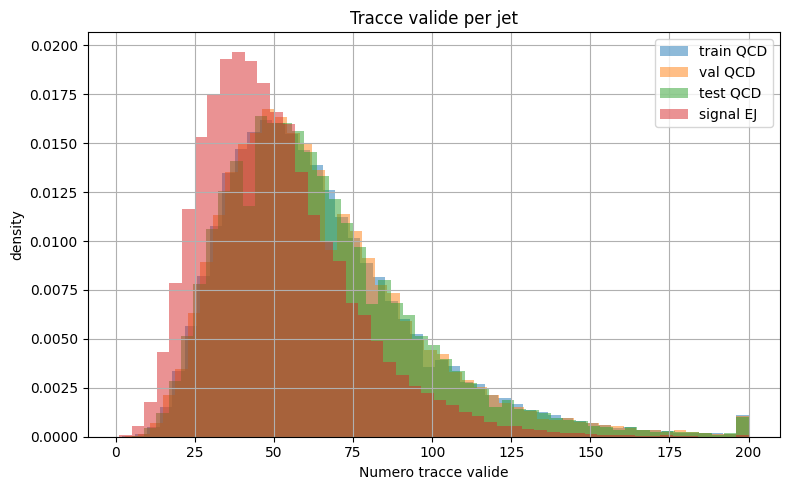

In [6]:
plt.figure(figsize=(8, 5))
plt.hist(mask_train.sum(axis=1), bins=50, density=True, alpha=0.5, label="train QCD")
plt.hist(mask_val.sum(axis=1), bins=50, density=True, alpha=0.5, label="val QCD")
plt.hist(mask_bkg_test.sum(axis=1), bins=50, density=True, alpha=0.5, label="test QCD")
plt.hist(mask_sig.sum(axis=1), bins=50, density=True, alpha=0.5, label="signal EJ")
plt.xlabel("Numero tracce valide")
plt.ylabel("density")
plt.title("Tracce valide per jet")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "valid_tracks_distribution.png", dpi=200)
plt.show()

## 7. Dataset e DataLoader

In [7]:
class JetTrackSetDataset(Dataset):
    def __init__(self, X_jets, X_tracks, mask):
        self.X_jets = torch.from_numpy(np.asarray(X_jets, dtype=np.float32))
        self.X_tracks = torch.from_numpy(np.asarray(X_tracks, dtype=np.float32))
        self.mask = torch.from_numpy(np.asarray(mask)).bool()

    def __len__(self):
        return self.X_jets.shape[0]

    def __getitem__(self, idx):
        return self.X_jets[idx], self.X_tracks[idx], self.mask[idx]


BATCH_SIZE = 256

train_loader = DataLoader(
    JetTrackSetDataset(X_jets_train, X_tracks_train, mask_train),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

val_loader = DataLoader(
    JetTrackSetDataset(X_jets_val, X_tracks_val, mask_val),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

center_loader = DataLoader(
    JetTrackSetDataset(X_jets_train, X_tracks_train, mask_train),
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available(),
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

Train batches: 391
Val batches: 196


## 8. Transformer Set Encoder

In [8]:
class TransformerSetEncoder(nn.Module):
    def __init__(
        self,
        n_track_features,
        n_jet_features,
        d_model=96,
        n_heads=4,
        n_layers=3,
        dim_feedforward=256,
        latent_dim=64,
        dropout=0.05,
    ):
        super().__init__()

        self.n_track_features = n_track_features
        self.n_jet_features = n_jet_features
        self.d_model = d_model
        self.latent_dim = latent_dim

        self.track_embed = nn.Sequential(
            nn.Linear(n_track_features, d_model),
            nn.LayerNorm(d_model),
            nn.SiLU(),
            nn.Linear(d_model, d_model),
            nn.LayerNorm(d_model),
            nn.SiLU(),
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )

        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=n_layers,
        )

        # Usiamo mean pooling + max pooling sulle tracce valide.
        pooled_dim = 2 * d_model

        self.jet_encoder = nn.Sequential(
            nn.Linear(n_jet_features, d_model),
            nn.LayerNorm(d_model),
            nn.SiLU(),
            nn.Linear(d_model, d_model),
            nn.LayerNorm(d_model),
            nn.SiLU(),
        )

        self.output = nn.Sequential(
            nn.Linear(pooled_dim + d_model, 2 * d_model),
            nn.LayerNorm(2 * d_model),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(2 * d_model, latent_dim),
        )

    def forward(self, x_jets, x_tracks, mask):
        # x_tracks: [B, N, F]
        # mask: [B, N], True per tracce valide.
        h = self.track_embed(x_tracks)

        # Transformer usa True per le posizioni da ignorare.
        key_padding_mask = ~mask
        h = self.transformer(h, src_key_padding_mask=key_padding_mask)

        mask_f = mask.unsqueeze(-1).float()
        valid_counts = mask_f.sum(dim=1).clamp_min(1.0)

        mean_pool = (h * mask_f).sum(dim=1) / valid_counts

        h_for_max = h.masked_fill(~mask.unsqueeze(-1), -1e9)
        max_pool = h_for_max.max(dim=1).values

        # Se un evento fosse senza tracce valide, evita -1e9.
        max_pool = torch.where(
            torch.isfinite(max_pool),
            max_pool,
            torch.zeros_like(max_pool),
        )

        jet_h = self.jet_encoder(x_jets)

        z = self.output(torch.cat([mean_pool, max_pool, jet_h], dim=1))

        return z

## 9. Crea modello

In [9]:
D_MODEL = 128
N_HEADS = 4
N_LAYERS = 4
DIM_FEEDFORWARD = 512
LATENT_DIM = 64
DROPOUT = 0.05

LR = 5e-5
WEIGHT_DECAY = 1e-5

N_EPOCHS = 150
PATIENCE = 25


model = TransformerSetEncoder(
    n_track_features=n_track_features,
    n_jet_features=n_jet_features,
    d_model=D_MODEL,
    n_heads=N_HEADS,
    n_layers=N_LAYERS,
    dim_feedforward=DIM_FEEDFORWARD,
    latent_dim=LATENT_DIM,
    dropout=DROPOUT,
).to(device)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY,
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=5,
)

print(model)
print("Parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

TransformerSetEncoder(
  (track_embed): Sequential(
    (0): Linear(in_features=16, out_features=128, bias=True)
    (1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (2): SiLU()
    (3): Linear(in_features=128, out_features=128, bias=True)
    (4): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (5): SiLU()
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=128, out_features=128, bias=True)
        )
        (linear1): Linear(in_features=128, out_features=512, bias=True)
        (dropout): Dropout(p=0.05, inplace=False)
        (linear2): Linear(in_features=512, out_features=128, bias=True)
        (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.05, inplace=False)
        (dropout2): 

## 10. Inizializzazione centro SVDD

In [10]:
@torch.no_grad()
def compute_center(model, loader, eps=1e-6):
    model.eval()

    zs = []

    for x_jets, x_tracks, mask in loader:
        x_jets = x_jets.to(device, non_blocking=True)
        x_tracks = x_tracks.to(device, non_blocking=True)
        mask = mask.to(device, non_blocking=True)

        z = model(x_jets, x_tracks, mask)
        zs.append(z.cpu())

    z_all = torch.cat(zs, dim=0)
    c = z_all.mean(dim=0)

    # Evita coordinate esattamente zero, come spesso consigliato in Deep SVDD.
    c[(torch.abs(c) < eps) & (c < 0)] = -eps
    c[(torch.abs(c) < eps) & (c >= 0)] = eps

    return c.to(device)


center = compute_center(model, center_loader)

print("center shape:", center.shape)
print("center mean/std:", center.mean().item(), center.std().item())
print("center min/max:", center.min().item(), center.max().item())

center shape: torch.Size([64])
center mean/std: -0.02310224249958992 0.3057292699813843
center min/max: -0.6761320233345032 0.9035069346427917


## 11. Loss e training Deep SVDD

In [11]:
def svdd_loss(z, center):
    dist2 = torch.sum((z - center.unsqueeze(0)) ** 2, dim=1)
    return dist2.mean(), dist2


def evaluate_svdd(model, loader, center):
    model.eval()

    total_loss = 0.0
    total_items = 0

    with torch.no_grad():
        for x_jets, x_tracks, mask in loader:
            x_jets = x_jets.to(device, non_blocking=True)
            x_tracks = x_tracks.to(device, non_blocking=True)
            mask = mask.to(device, non_blocking=True)

            z = model(x_jets, x_tracks, mask)
            loss, _ = svdd_loss(z, center)

            bs = x_jets.shape[0]
            total_loss += loss.item() * bs
            total_items += bs

    return total_loss / max(total_items, 1)

In [12]:
train_losses = []
val_losses = []
lr_history = []

best_val_loss = np.inf
best_epoch = -1
best_state_dict = None
epochs_without_improvement = 0

for epoch in range(N_EPOCHS):
    model.train()

    total_loss = 0.0
    total_items = 0

    for x_jets, x_tracks, mask in train_loader:
        x_jets = x_jets.to(device, non_blocking=True)
        x_tracks = x_tracks.to(device, non_blocking=True)
        mask = mask.to(device, non_blocking=True)

        optimizer.zero_grad()

        z = model(x_jets, x_tracks, mask)
        loss, _ = svdd_loss(z, center)

        if not torch.isfinite(loss):
            raise RuntimeError("Loss non finita.")

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        bs = x_jets.shape[0]
        total_loss += loss.item() * bs
        total_items += bs

    train_loss = total_loss / max(total_items, 1)
    val_loss = evaluate_svdd(model, val_loader, center)

    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]["lr"]

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    lr_history.append(current_lr)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch + 1
        best_state_dict = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    print(
        f"Epoch {epoch+1:03d}/{N_EPOCHS} | "
        f"train={train_loss:.6f} | "
        f"val={val_loss:.6f} | "
        f"best={best_val_loss:.6f} @ {best_epoch} | "
        f"lr={current_lr:.2e}"
    )

    if epochs_without_improvement >= PATIENCE:
        print("Early stopping.")
        break

if best_state_dict is not None:
    model.load_state_dict(best_state_dict)
    print(f"Loaded best model from epoch {best_epoch} with val loss={best_val_loss:.6f}")

df_history = pd.DataFrame({
    "epoch": np.arange(1, len(train_losses) + 1),
    "train_svdd_loss": train_losses,
    "val_svdd_loss": val_losses,
    "lr": lr_history,
})

df_history.to_csv(OUTPUT_DIR / "transformer_deep_svdd_training_history.csv", index=False)
print("Saved:", OUTPUT_DIR / "transformer_deep_svdd_training_history.csv")

Epoch 001/150 | train=0.161774 | val=0.008379 | best=0.008379 @ 1 | lr=5.00e-05
Epoch 002/150 | train=0.044987 | val=0.005210 | best=0.005210 @ 2 | lr=5.00e-05
Epoch 003/150 | train=0.028258 | val=0.002606 | best=0.002606 @ 3 | lr=5.00e-05
Epoch 004/150 | train=0.020256 | val=0.002078 | best=0.002078 @ 4 | lr=5.00e-05
Epoch 005/150 | train=0.014232 | val=0.001809 | best=0.001809 @ 5 | lr=5.00e-05
Epoch 006/150 | train=0.010652 | val=0.001732 | best=0.001732 @ 6 | lr=5.00e-05
Epoch 007/150 | train=0.008490 | val=0.001259 | best=0.001259 @ 7 | lr=5.00e-05
Epoch 008/150 | train=0.007006 | val=0.001940 | best=0.001259 @ 7 | lr=5.00e-05
Epoch 009/150 | train=0.006003 | val=0.000878 | best=0.000878 @ 9 | lr=5.00e-05
Epoch 010/150 | train=0.005125 | val=0.000599 | best=0.000599 @ 10 | lr=5.00e-05
Epoch 011/150 | train=0.004451 | val=0.000539 | best=0.000539 @ 11 | lr=5.00e-05
Epoch 012/150 | train=0.003892 | val=0.000701 | best=0.000539 @ 11 | lr=5.00e-05
Epoch 013/150 | train=0.003446 | val=

## 12. Training plots

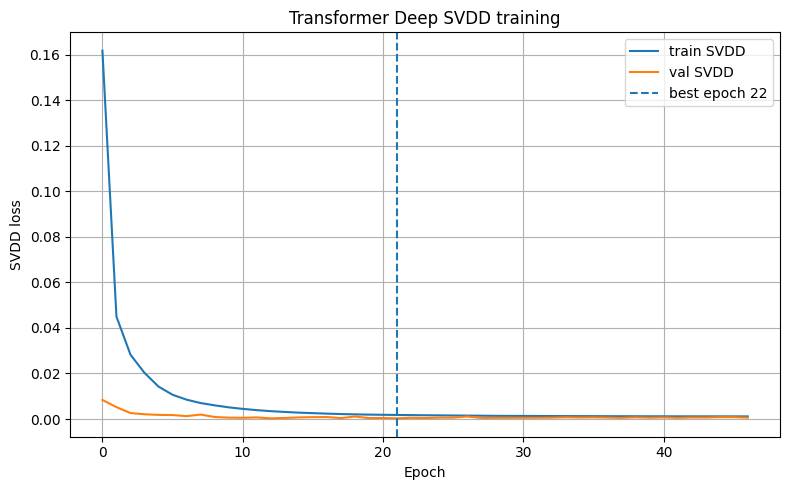

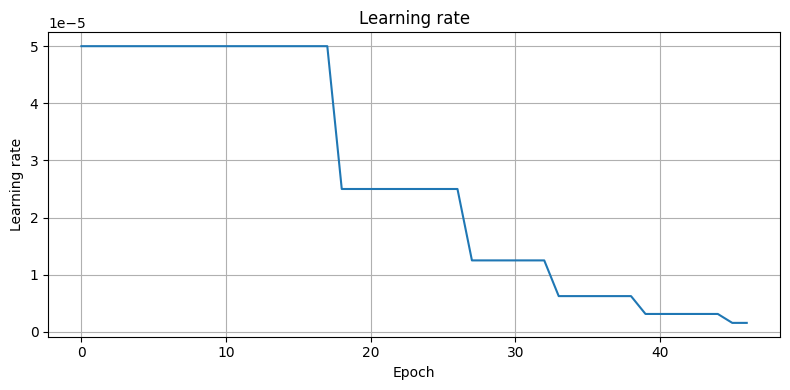

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="train SVDD")
plt.plot(val_losses, label="val SVDD")
plt.axvline(best_epoch - 1, linestyle="--", label=f"best epoch {best_epoch}")
plt.xlabel("Epoch")
plt.ylabel("SVDD loss")
plt.title("Transformer Deep SVDD training")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "transformer_deep_svdd_training_curve.png", dpi=200)
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(lr_history)
plt.xlabel("Epoch")
plt.ylabel("Learning rate")
plt.title("Learning rate")
plt.grid(True)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "transformer_deep_svdd_lr_schedule.png", dpi=200)
plt.show()

## 13. Calcolo score SVDD

In [14]:
@torch.no_grad()
def compute_svdd_scores(model, X_jets, X_tracks, mask, center, batch_size=1024):
    dataset = JetTrackSetDataset(X_jets, X_tracks, mask)
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )

    model.eval()

    scores = []
    embeddings = []

    for x_jets, x_tracks, mask_batch in loader:
        x_jets = x_jets.to(device, non_blocking=True)
        x_tracks = x_tracks.to(device, non_blocking=True)
        mask_batch = mask_batch.to(device, non_blocking=True)

        z = model(x_jets, x_tracks, mask_batch)
        dist2 = torch.sum((z - center.unsqueeze(0)) ** 2, dim=1)

        scores.append(dist2.cpu().numpy())
        embeddings.append(z.cpu().numpy())

    return np.concatenate(scores), np.concatenate(embeddings, axis=0)


scores_train, Z_train = compute_svdd_scores(model, X_jets_train, X_tracks_train, mask_train, center)
scores_val, Z_val = compute_svdd_scores(model, X_jets_val, X_tracks_val, mask_val, center)
scores_bkg_test, Z_bkg_test = compute_svdd_scores(model, X_jets_bkg_test, X_tracks_bkg_test, mask_bkg_test, center)
scores_sig, Z_sig = compute_svdd_scores(model, X_jets_sig, X_tracks_sig, mask_sig, center)

for name, s in [
    ("train QCD", scores_train),
    ("val QCD", scores_val),
    ("test QCD", scores_bkg_test),
    ("signal EJ", scores_sig),
]:
    print(name, "mean", float(np.mean(s)), "std", float(np.std(s)), "q", np.percentile(s, [1, 50, 99]))

train QCD mean 0.0002909255272243172 std 4.9308731831843033e-05 q [0.00019119 0.00028775 0.00042036]
val QCD mean 0.00029073652694933116 std 4.930746217723936e-05 q [0.00019087 0.00028739 0.00041989]
test QCD mean 0.0002907578309532255 std 4.9421272706240416e-05 q [0.0001912  0.00028729 0.00042034]
signal EJ mean 0.0003162341599818319 std 6.702410610159859e-05 q [0.00019867 0.00030746 0.0005161 ]


## 14. ROC/AUC e metriche a mistag fissato

In [15]:
def orient_scores(bg, sig):
    y = np.concatenate([np.zeros_like(bg), np.ones_like(sig)])
    s = np.concatenate([bg, sig])

    auc = roc_auc_score(y, s)
    auc_inv = roc_auc_score(y, -s)

    if auc_inv > auc:
        return -bg, -sig, auc_inv, True, auc, auc_inv
    return bg, sig, auc, False, auc, auc_inv


def evaluate_scores(bg, sig, model_name="Transformer Deep SVDD", score_name="SVDD"):
    bg_o, sig_o, best_auc, flipped, auc, auc_inv = orient_scores(bg, sig)

    y = np.concatenate([np.zeros_like(bg_o), np.ones_like(sig_o)])
    s = np.concatenate([bg_o, sig_o])

    fpr, tpr, thresholds = roc_curve(y, s)

    rows = []
    for mistag in [0.30, 0.10, 0.05, 0.01, 0.001]:
        threshold = np.quantile(bg_o, 1.0 - mistag)
        eff = np.mean(sig_o >= threshold)
        actual_mistag = np.mean(bg_o >= threshold)

        rows.append({
            "model": model_name,
            "score": score_name,
            "auc": best_auc,
            "raw_auc": auc,
            "auc_inverted": auc_inv,
            "flipped": flipped,
            "mistag_target": mistag,
            "actual_mistag": actual_mistag,
            "signal_efficiency": eff,
            "threshold": threshold,
        })

    return {
        "bg_oriented": bg_o,
        "sig_oriented": sig_o,
        "best_auc": best_auc,
        "auc": auc,
        "auc_inverted": auc_inv,
        "flipped": flipped,
        "fpr": fpr,
        "tpr": tpr,
        "thresholds": thresholds,
        "eff_table": pd.DataFrame(rows),
    }


eval_main = evaluate_scores(scores_bkg_test, scores_sig)

print("AUC:", eval_main["auc"])
print("AUC inverted:", eval_main["auc_inverted"])
print("Best AUC:", eval_main["best_auc"])
print("Flipped:", eval_main["flipped"])

display(eval_main["eff_table"])

AUC: 0.6088452976680384
AUC inverted: 0.3911547023319616
Best AUC: 0.6088452976680384
Flipped: False


,model,score,auc,raw_auc,auc_inverted,flipped,mistag_target,actual_mistag,signal_efficiency,threshold
0,Transformer Deep SVDD,SVDD,0.608845,0.608845,0.391155,False,0.300,0.300,0.459711,0.000314
1,Transformer Deep SVDD,SVDD,0.608845,0.608845,0.391155,False,0.100,0.100,0.238732,0.000355
2,Transformer Deep SVDD,SVDD,0.608845,0.608845,0.391155,False,0.050,0.050,0.160139,0.000377
3,Transformer Deep SVDD,SVDD,0.608845,0.608845,0.391155,False,0.010,0.010,0.067732,0.000420
4,Transformer Deep SVDD,SVDD,0.608845,0.608845,0.391155,False,0.001,0.001,0.021448,0.000478


## 15. Plot ROC, score distribution, efficiency vs mistag

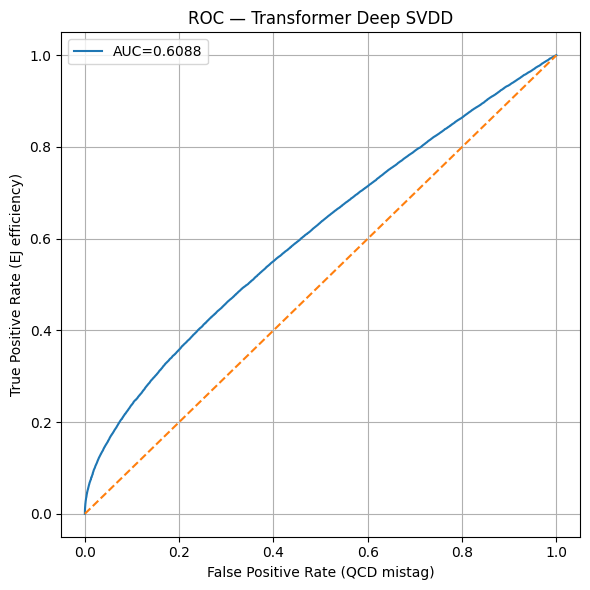

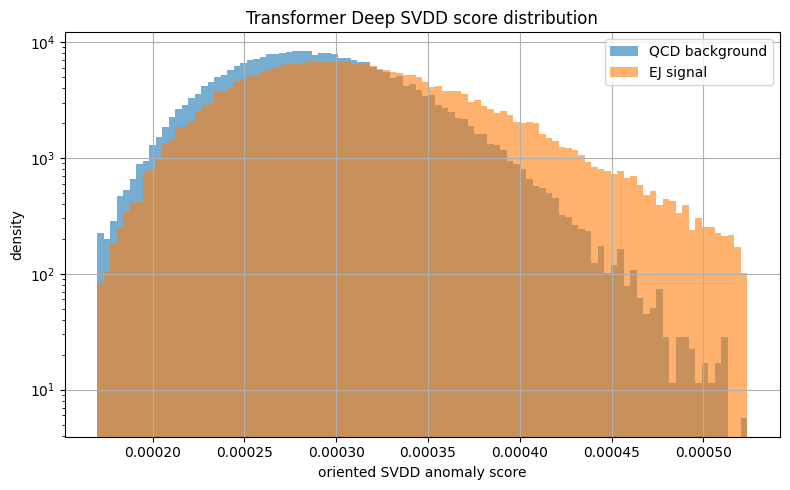

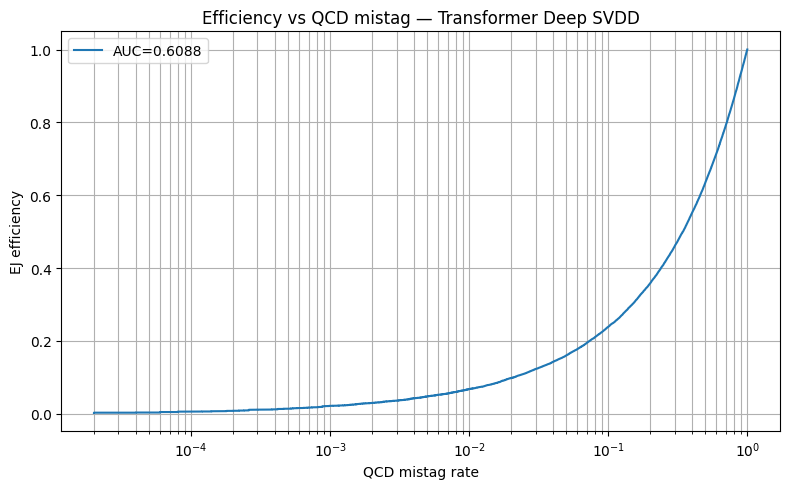

In [16]:
bg_o = eval_main["bg_oriented"]
sig_o = eval_main["sig_oriented"]

plt.figure(figsize=(6, 6))
plt.plot(eval_main["fpr"], eval_main["tpr"], label=f"AUC={eval_main['best_auc']:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate (QCD mistag)")
plt.ylabel("True Positive Rate (EJ efficiency)")
plt.title("ROC — Transformer Deep SVDD")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "transformer_deep_svdd_roc.png", dpi=200)
plt.show()

all_scores = np.concatenate([bg_o, sig_o])
lo = np.percentile(all_scores, 0.1)
hi = np.percentile(all_scores, 99.5)

plt.figure(figsize=(8, 5))
plt.hist(bg_o, bins=100, range=(lo, hi), density=True, alpha=0.6, label="QCD background")
plt.hist(sig_o, bins=100, range=(lo, hi), density=True, alpha=0.6, label="EJ signal")
plt.yscale("log")
plt.xlabel("oriented SVDD anomaly score")
plt.ylabel("density")
plt.title("Transformer Deep SVDD score distribution")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "transformer_deep_svdd_score_distribution.png", dpi=200)
plt.show()

fpr = eval_main["fpr"]
tpr = eval_main["tpr"]
mask_fpr = fpr > 0

plt.figure(figsize=(8, 5))
plt.plot(fpr[mask_fpr], tpr[mask_fpr], label=f"AUC={eval_main['best_auc']:.4f}")
plt.xscale("log")
plt.xlabel("QCD mistag rate")
plt.ylabel("EJ efficiency")
plt.title("Efficiency vs QCD mistag — Transformer Deep SVDD")
plt.legend()
plt.grid(True, which="both")
plt.tight_layout()
plt.savefig(PLOTS_DIR / "transformer_deep_svdd_efficiency_vs_mistag.png", dpi=200)
plt.show()

## 16. Background consistency checks

,comparison,auc,auc_inverted,best_auc
0,train QCD vs val QCD,0.498600,0.501400,0.501400
1,train QCD vs test QCD,0.498598,0.501402,0.501402
2,val QCD vs test QCD,0.499996,0.500004,0.500004


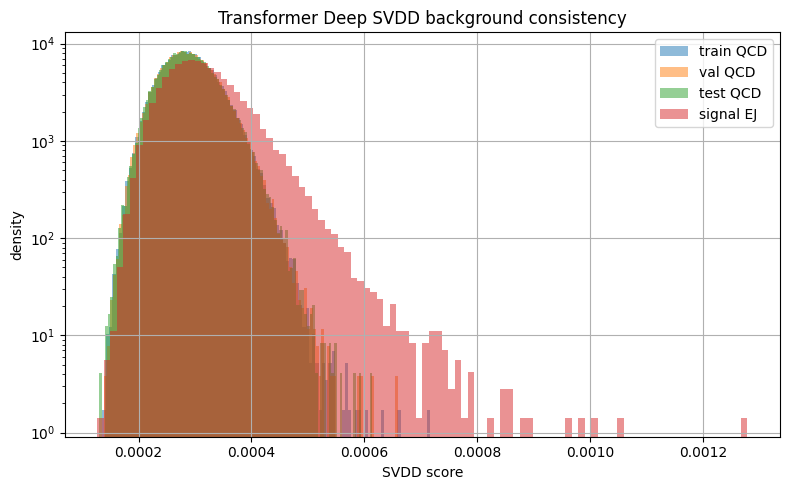

In [17]:
def bg_vs_bg_auc(a, b, name_a, name_b):
    y = np.concatenate([np.zeros_like(a), np.ones_like(b)])
    s = np.concatenate([a, b])

    auc = roc_auc_score(y, s)
    auc_inv = roc_auc_score(y, -s)

    return {
        "comparison": f"{name_a} vs {name_b}",
        "auc": auc,
        "auc_inverted": auc_inv,
        "best_auc": max(auc, auc_inv),
    }


bg_checks = pd.DataFrame([
    bg_vs_bg_auc(scores_train, scores_val, "train QCD", "val QCD"),
    bg_vs_bg_auc(scores_train, scores_bkg_test, "train QCD", "test QCD"),
    bg_vs_bg_auc(scores_val, scores_bkg_test, "val QCD", "test QCD"),
])

display(bg_checks)

plt.figure(figsize=(8, 5))
plt.hist(scores_train, bins=100, density=True, alpha=0.5, label="train QCD")
plt.hist(scores_val, bins=100, density=True, alpha=0.5, label="val QCD")
plt.hist(scores_bkg_test, bins=100, density=True, alpha=0.5, label="test QCD")
plt.hist(scores_sig, bins=100, density=True, alpha=0.5, label="signal EJ")
plt.yscale("log")
plt.xlabel("SVDD score")
plt.ylabel("density")
plt.title("Transformer Deep SVDD background consistency")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "transformer_deep_svdd_background_consistency.png", dpi=200)
plt.show()

## 17. Diagnostica supervisionata sugli embedding

In [18]:
# Questa NON è la metrica principale.
# Serve solo a capire quanta informazione discriminante è presente nello spazio latente.

X_clf = np.concatenate([Z_bkg_test, Z_sig], axis=0)
y_clf = np.concatenate([
    np.zeros(Z_bkg_test.shape[0], dtype=np.int64),
    np.ones(Z_sig.shape[0], dtype=np.int64),
])

X_tr, X_te, y_tr, y_te = train_test_split(
    X_clf,
    y_clf,
    test_size=0.3,
    random_state=SEED,
    stratify=y_clf,
)

clf = LogisticRegression(max_iter=3000)
clf.fit(X_tr, y_tr)

proba = clf.predict_proba(X_te)[:, 1]
auc_latent_logreg = roc_auc_score(y_te, proba)

print("Supervised logistic regression AUC on Deep SVDD embeddings:", auc_latent_logreg)

Supervised logistic regression AUC on Deep SVDD embeddings: 0.9309070037654653


## 18. Permutation invariance check

In [19]:
def permutation_invariance_check(model, X_jets, X_tracks, mask, center, n_samples=512):
    model.eval()

    n_samples = min(n_samples, X_jets.shape[0])

    Xj = torch.from_numpy(X_jets[:n_samples]).float().to(device)
    Xt = torch.from_numpy(X_tracks[:n_samples]).float().to(device)
    M = torch.from_numpy(mask[:n_samples]).bool().to(device)

    B, N, F = Xt.shape

    perm = torch.stack([torch.randperm(N, device=device) for _ in range(B)], dim=0)
    perm_exp = perm.unsqueeze(-1).expand(B, N, F)

    Xt_perm = torch.gather(Xt, dim=1, index=perm_exp)
    M_perm = torch.gather(M, dim=1, index=perm)

    with torch.no_grad():
        z = model(Xj, Xt, M)
        z_p = model(Xj, Xt_perm, M_perm)

        dz = torch.mean(torch.abs(z - z_p)).item()

        score = torch.sum((z - center.unsqueeze(0)) ** 2, dim=1)
        score_p = torch.sum((z_p - center.unsqueeze(0)) ** 2, dim=1)

        ds = torch.mean(torch.abs(score - score_p)).item()

    print("Mean abs difference latent after track permutation:", dz)
    print("Mean abs difference score after track permutation:", ds)


permutation_invariance_check(model, X_jets_bkg_test, X_tracks_bkg_test, mask_bkg_test, center, n_samples=512)

Mean abs difference latent after track permutation: 4.6632258090539835e-06
Mean abs difference score after track permutation: 7.384389846265549e-07


## 19. Feature importance tramite permutation importance

,feature_type,feature,base_auc,permuted_auc,importance
0,jet,ECF1_clusterSoftDrop,0.603417,0.505154,0.098263
1,jet,Tau2_clusterSoftDrop,0.603417,0.509537,0.093880
2,track,pt_log1p,0.603417,0.528258,0.075158
3,jet,energy,0.603417,0.530099,0.073318
4,jet,Tau3_clusterSoftDrop,0.603417,0.549575,0.053841
5,jet,mass,0.603417,0.550513,0.052903
6,jet,Qw_clusterSoftDrop,0.603417,0.551549,0.051867
7,track,numberOfInnermostPixelLayerHits,0.603417,0.576093,0.027324
8,jet,ECF2_clusterSoftDrop,0.603417,0.584730,0.018687
9,track,numberOfPixelSharedHits,0.603417,0.588084,0.015333


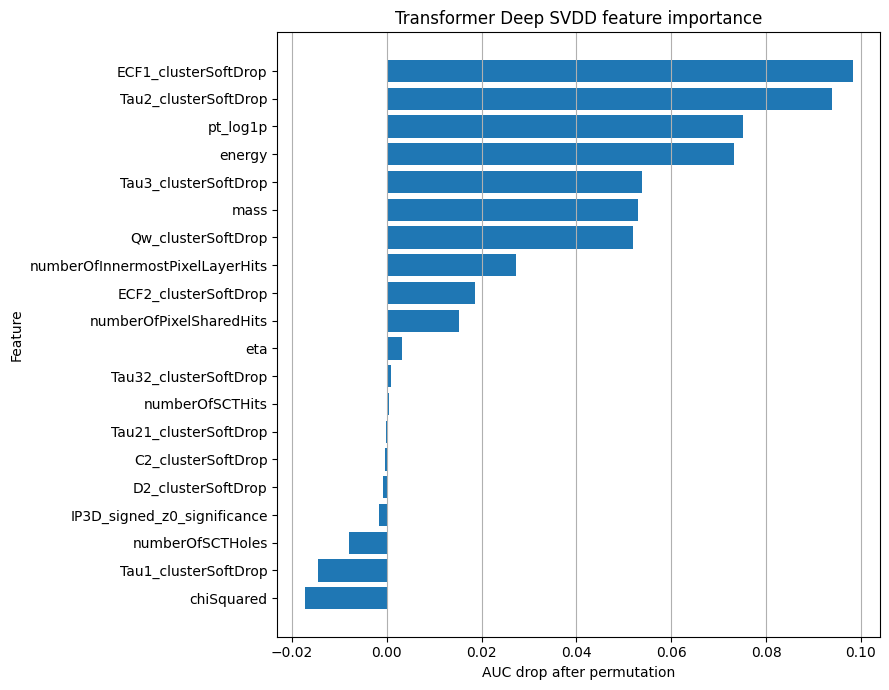

In [20]:
# Questa sezione è opzionale ma utile per il report.
# Misura quanto cala l'AUC quando rompiamo l'associazione tra una feature e l'evento.
#
# Per velocità usa un sottoinsieme di eventi.
# Aumenta MAX_EVENTS_PER_CLASS se hai GPU e vuoi stime più precise.

DO_FEATURE_IMPORTANCE = True
MAX_EVENTS_PER_CLASS = 5000

def subset_for_importance(Xj_bg, Xt_bg, m_bg, Xj_sig, Xt_sig, m_sig, max_events=5000):
    rng = np.random.default_rng(SEED)

    n_bg = min(max_events, Xj_bg.shape[0])
    n_sig = min(max_events, Xj_sig.shape[0])

    idx_bg = rng.choice(Xj_bg.shape[0], size=n_bg, replace=False)
    idx_sig = rng.choice(Xj_sig.shape[0], size=n_sig, replace=False)

    return (
        Xj_bg[idx_bg].copy(),
        Xt_bg[idx_bg].copy(),
        m_bg[idx_bg].copy(),
        Xj_sig[idx_sig].copy(),
        Xt_sig[idx_sig].copy(),
        m_sig[idx_sig].copy(),
    )


def best_auc_from_scores(bg, sig):
    y = np.concatenate([np.zeros_like(bg), np.ones_like(sig)])
    s = np.concatenate([bg, sig])
    return max(roc_auc_score(y, s), roc_auc_score(y, -s))


def permutation_importance_transformer(
    model,
    center,
    Xj_bg,
    Xt_bg,
    m_bg,
    Xj_sig,
    Xt_sig,
    m_sig,
    jet_feature_names,
    track_feature_names,
):
    rng = np.random.default_rng(SEED)

    base_bg, _ = compute_svdd_scores(model, Xj_bg, Xt_bg, m_bg, center, batch_size=1024)
    base_sig, _ = compute_svdd_scores(model, Xj_sig, Xt_sig, m_sig, center, batch_size=1024)
    base_auc = best_auc_from_scores(base_bg, base_sig)

    rows = []

    # Jet feature permutation.
    for j, name in enumerate(jet_feature_names):
        Xj_all = np.concatenate([Xj_bg, Xj_sig], axis=0).copy()
        Xt_all = np.concatenate([Xt_bg, Xt_sig], axis=0).copy()
        m_all = np.concatenate([m_bg, m_sig], axis=0).copy()

        Xj_all[:, j] = rng.permutation(Xj_all[:, j])

        n_bg = Xj_bg.shape[0]
        s_bg, _ = compute_svdd_scores(model, Xj_all[:n_bg], Xt_all[:n_bg], m_all[:n_bg], center, batch_size=1024)
        s_sig, _ = compute_svdd_scores(model, Xj_all[n_bg:], Xt_all[n_bg:], m_all[n_bg:], center, batch_size=1024)

        auc_perm = best_auc_from_scores(s_bg, s_sig)

        rows.append({
            "feature_type": "jet",
            "feature": name,
            "base_auc": base_auc,
            "permuted_auc": auc_perm,
            "importance": base_auc - auc_perm,
        })

    # Track feature permutation.
    for j, name in enumerate(track_feature_names):
        Xj_all = np.concatenate([Xj_bg, Xj_sig], axis=0).copy()
        Xt_all = np.concatenate([Xt_bg, Xt_sig], axis=0).copy()
        m_all = np.concatenate([m_bg, m_sig], axis=0).copy()

        valid_values = Xt_all[:, :, j][m_all].copy()
        valid_values = rng.permutation(valid_values)
        Xt_all[:, :, j][m_all] = valid_values

        # Mantieni padding invalido a zero.
        Xt_all[~m_all] = 0.0

        n_bg = Xj_bg.shape[0]
        s_bg, _ = compute_svdd_scores(model, Xj_all[:n_bg], Xt_all[:n_bg], m_all[:n_bg], center, batch_size=1024)
        s_sig, _ = compute_svdd_scores(model, Xj_all[n_bg:], Xt_all[n_bg:], m_all[n_bg:], center, batch_size=1024)

        auc_perm = best_auc_from_scores(s_bg, s_sig)

        rows.append({
            "feature_type": "track",
            "feature": name,
            "base_auc": base_auc,
            "permuted_auc": auc_perm,
            "importance": base_auc - auc_perm,
        })

    return pd.DataFrame(rows).sort_values("importance", ascending=False).reset_index(drop=True)


if DO_FEATURE_IMPORTANCE:
    imp_inputs = subset_for_importance(
        X_jets_bkg_test,
        X_tracks_bkg_test,
        mask_bkg_test,
        X_jets_sig,
        X_tracks_sig,
        mask_sig,
        max_events=MAX_EVENTS_PER_CLASS,
    )

    df_importance = permutation_importance_transformer(
        model,
        center,
        *imp_inputs,
        jet_feature_names=jet_feature_names,
        track_feature_names=track_feature_names,
    )

    df_importance.to_csv(OUTPUT_DIR / "transformer_deep_svdd_feature_importance.csv", index=False)
    display(df_importance.head(20))

    top = df_importance.head(20).iloc[::-1]

    plt.figure(figsize=(9, 7))
    plt.barh(top["feature"], top["importance"])
    plt.xlabel("AUC drop after permutation")
    plt.ylabel("Feature")
    plt.title("Transformer Deep SVDD feature importance")
    plt.grid(True, axis="x")
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / "transformer_deep_svdd_feature_importance.png", dpi=200)
    plt.show()
else:
    df_importance = pd.DataFrame()
    print("Feature importance skipped.")

## 20. Salvataggio finale

In [21]:
results_summary = {
    "model": "Transformer Deep SVDD",
    "score": "SVDD distance",
    "auc": float(eval_main["auc"]),
    "auc_inverted": float(eval_main["auc_inverted"]),
    "best_auc": float(eval_main["best_auc"]),
    "flipped": bool(eval_main["flipped"]),
    "auc_latent_logreg": float(auc_latent_logreg),
    "n_track_features": int(n_track_features),
    "n_jet_features": int(n_jet_features),
    "max_tracks": int(max_tracks),
    "d_model": int(D_MODEL),
    "n_heads": int(N_HEADS),
    "n_layers": int(N_LAYERS),
    "dim_feedforward": int(DIM_FEEDFORWARD),
    "latent_dim": int(LATENT_DIM),
    "dropout": float(DROPOUT),
    "learning_rate": float(LR),
    "weight_decay": float(WEIGHT_DECAY),
    "batch_size": int(BATCH_SIZE),
    "best_epoch": int(best_epoch),
    "best_val_loss": float(best_val_loss),
}

for _, row in bg_checks.iterrows():
    key = row["comparison"].replace(" ", "_").replace("vs", "VS")
    results_summary[f"{key}_best_auc"] = float(row["best_auc"])

with open(OUTPUT_DIR / "transformer_deep_svdd_config.json", "w") as f:
    json.dump(
        {
            **results_summary,
            "processed_path": str(PROCESSED_PATH),
            "jet_feature_names": jet_feature_names,
            "track_feature_names": track_feature_names,
        },
        f,
        indent=2,
    )

eval_main["eff_table"].to_csv(OUTPUT_DIR / "transformer_deep_svdd_results.csv", index=False)
bg_checks.to_csv(OUTPUT_DIR / "transformer_deep_svdd_background_checks.csv", index=False)

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "center": center.detach().cpu(),
        "config": results_summary,
        "jet_feature_names": jet_feature_names,
        "track_feature_names": track_feature_names,
        "train_losses": train_losses,
        "val_losses": val_losses,
        "lr_history": lr_history,
    },
    OUTPUT_DIR / "transformer_deep_svdd_model.pt",
)

np.savez_compressed(
    OUTPUT_DIR / "transformer_deep_svdd_scores.npz",
    scores_train=scores_train,
    scores_val=scores_val,
    scores_bkg_test=scores_bkg_test,
    scores_sig=scores_sig,
    Z_train=Z_train,
    Z_val=Z_val,
    Z_bkg_test=Z_bkg_test,
    Z_sig=Z_sig,
    center=center.detach().cpu().numpy(),
    bg_oriented=eval_main["bg_oriented"],
    sig_oriented=eval_main["sig_oriented"],
    fpr=eval_main["fpr"],
    tpr=eval_main["tpr"],
    thresholds=eval_main["thresholds"],
    jet_feature_names=np.array(jet_feature_names, dtype=object),
    track_feature_names=np.array(track_feature_names, dtype=object),
    auc=np.array(eval_main["auc"], dtype=np.float32),
    auc_inverted=np.array(eval_main["auc_inverted"], dtype=np.float32),
    best_auc=np.array(eval_main["best_auc"], dtype=np.float32),
    auc_latent_logreg=np.array(auc_latent_logreg, dtype=np.float32),
)

print("Saved:")
print(OUTPUT_DIR / "transformer_deep_svdd_model.pt")
print(OUTPUT_DIR / "transformer_deep_svdd_scores.npz")
print(OUTPUT_DIR / "transformer_deep_svdd_results.csv")
print(OUTPUT_DIR / "transformer_deep_svdd_background_checks.csv")
print(OUTPUT_DIR / "transformer_deep_svdd_config.json")
if DO_FEATURE_IMPORTANCE:
    print(OUTPUT_DIR / "transformer_deep_svdd_feature_importance.csv")
print("plots:", PLOTS_DIR)

Saved:
..\outputs\transformer_deep_svdd\transformer_deep_svdd_model.pt
..\outputs\transformer_deep_svdd\transformer_deep_svdd_scores.npz
..\outputs\transformer_deep_svdd\transformer_deep_svdd_results.csv
..\outputs\transformer_deep_svdd\transformer_deep_svdd_background_checks.csv
..\outputs\transformer_deep_svdd\transformer_deep_svdd_config.json
..\outputs\transformer_deep_svdd\transformer_deep_svdd_feature_importance.csv
plots: ..\outputs\transformer_deep_svdd\plots
